# CME/CBOT Corn futures: a continuous nearby series

This demo uses the CME Group / CBOT Corn futures root ZC and shows how the
Barchart utilities turn individual contract histories into nearby lines.
It uses deterministic offline data by default. Set USE_LIVE_DATA to True in
the final cell to fetch current histories from Barchart.



In [1]:
from pathlib import Path
import sys

candidate_roots = [Path.cwd(), *Path.cwd().parents]
repo_root = next(
    (candidate for candidate in candidate_roots if (candidate / "Barchart").is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError("Run this demo from a checkout containing the Barchart folder.")
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from Barchart import (
    BarchartFetcher,
    BarchartHistoricalData,
    ContinuousFuturesBuilder,
    expiry_key,
    parse_symbol,
)

START = "2024-01-02"
END = "2025-12-31"
CORN_ROOT = "ZC"
CORN_CYCLE = ["H", "K", "N", "U", "Z"]



## 1. Build a deterministic offline contract set

The synthetic histories share a market path but have contract-level offsets
and noise. Each contract is only available during a plausible pre-expiry
window, making nearby selection and roll segments visible without presenting
synthetic values as market prices.



In [2]:
def make_demo_contracts(start=START, end=END):
    dates = pd.bdate_range(start, end)
    rng = np.random.default_rng(2026)
    progress = np.arange(len(dates), dtype=float)
    market_path = 450 + 0.035 * progress + 13 * np.sin(progress / 75)

    symbols = [
        "ZCH24", "ZCK24", "ZCN24", "ZCU24", "ZCZ24",
        "ZCH25", "ZCK25", "ZCN25", "ZCU25", "ZCZ25", "ZCH26",
    ]
    contracts = {}
    for symbol in symbols:
        _, month, year, _ = parse_symbol(symbol)
        delivery_month = pd.Timestamp(year=year, month=month, day=1)
        active_start = delivery_month - pd.DateOffset(months=15)
        active_end = delivery_month - pd.DateOffset(months=1)
        mask = (dates >= active_start) & (dates <= active_end)
        contract_dates = dates[mask]
        positions = np.flatnonzero(mask)
        if len(contract_dates) == 0:
            continue

        contract_offset = 0.12 * (expiry_key(symbol) - expiry_key("ZCH24"))
        close = (
            market_path[positions]
            + contract_offset
            + rng.normal(0, 1.8, len(contract_dates))
        )
        contracts[symbol] = pd.DataFrame(
            {
                "date": contract_dates,
                "open": close - rng.uniform(0.2, 1.4, len(close)),
                "high": close + rng.uniform(0.5, 2.0, len(close)),
                "low": close - rng.uniform(0.5, 2.0, len(close)),
                "close": close,
                "volume": rng.integers(20_000, 160_000, len(close)),
                "openInterest": rng.integers(80_000, 500_000, len(close)),
            }
        )
    return contracts


contracts = make_demo_contracts()
display(
    pd.DataFrame(
        {
            "contract": list(contracts),
            "first_date": [frame["date"].min().date() for frame in contracts.values()],
            "last_date": [frame["date"].max().date() for frame in contracts.values()],
            "rows": [len(frame) for frame in contracts.values()],
        }
    )
)



,contract,first_date,last_date,rows
0,ZCH24,2024-01-02,2024-02-01,23
1,ZCK24,2024-01-02,2024-04-01,65
2,ZCN24,2024-01-02,2024-05-31,109
3,ZCU24,2024-01-02,2024-08-01,153
4,ZCZ24,2024-01-02,2024-11-01,219
5,ZCH25,2024-01-02,2025-01-31,284
6,ZCK25,2024-02-01,2025-04-01,304
7,ZCN25,2024-04-01,2025-05-30,305
8,ZCU25,2024-06-03,2025-08-01,305
9,ZCZ25,2024-09-02,2025-10-31,305


## 2. Select nearby lines and expose roll segments



In [3]:
builder = ContinuousFuturesBuilder(verbose=False)
nearby_1, segments_1 = builder.build(
    contracts,
    line_number=1,
    start=START,
    end=END,
    return_segments=True,
)
nearby_2, segments_2 = builder.build(
    contracts,
    line_number=2,
    start=START,
    end=END,
    return_segments=True,
)

display(
    pd.DataFrame(
        {
            "series": ["nearby 1", "nearby 2"],
            "rows": [len(nearby_1), len(nearby_2)],
            "contracts_used": [
                nearby_1["source_symbol"].nunique(),
                nearby_2["source_symbol"].nunique(),
            ],
            "rolls": [max(len(segments_1) - 1, 0), max(len(segments_2) - 1, 0)],
        }
    )
)
display(segments_1)



,series,rows,contracts_used,rolls
0,nearby 1,522,11,10
1,nearby 2,479,10,9


,segment_start,segment_end,line,source_symbol,n_rows
0,2024-01-02,2024-02-01,1,ZCH24,23
1,2024-02-02,2024-04-01,1,ZCK24,42
2,2024-04-02,2024-05-31,1,ZCN24,44
3,2024-06-03,2024-08-01,1,ZCU24,44
4,2024-08-02,2024-11-01,1,ZCZ24,66
5,2024-11-04,2025-01-31,1,ZCH25,65
6,2025-02-03,2025-04-01,1,ZCK25,42
7,2025-04-02,2025-05-30,1,ZCN25,43
8,2025-06-02,2025-08-01,1,ZCU25,45
9,2025-08-04,2025-10-31,1,ZCZ25,65


## 3. Plot the continuous series

Gold markers show where the selected source contract changes. The lower
panel compares the first and second nearby lines.



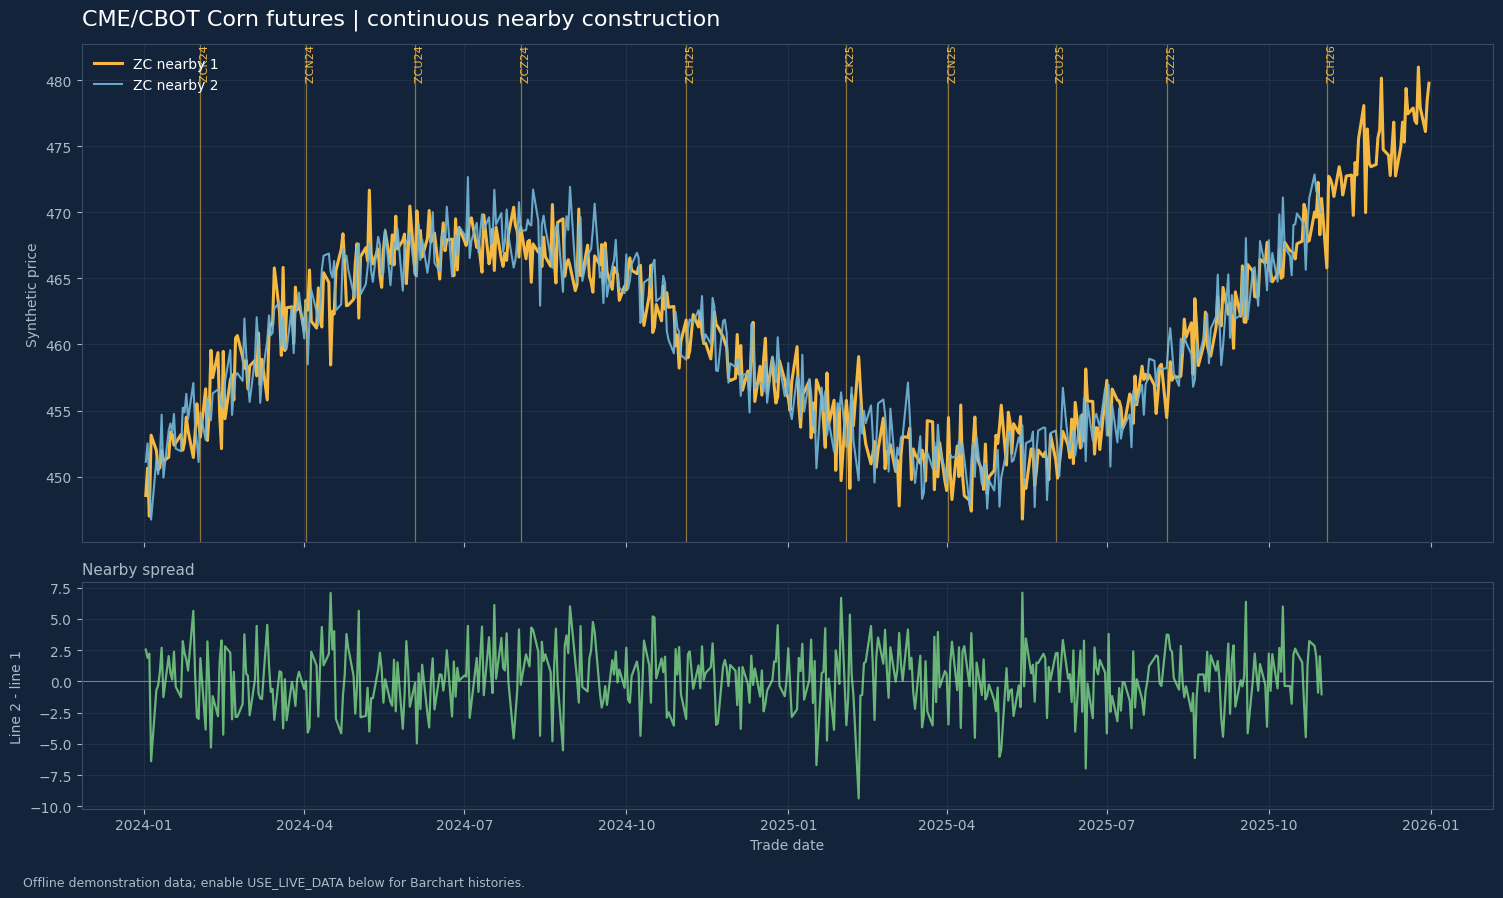

In [4]:
navy = "#13233A"
gold = "#F4B942"
field_green = "#69B578"
sky = "#73B7D8"
muted = "#AEB9C6"

plt.style.use("dark_background")
fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1]},
)
fig.patch.set_facecolor(navy)
for axis in axes:
    axis.set_facecolor(navy)
    axis.grid(True, color="#3A4A60", alpha=0.35)
    axis.tick_params(colors=muted)
    for spine in axis.spines.values():
        spine.set_color("#3A4A60")

axes[0].plot(
    nearby_1["date"],
    nearby_1["close"],
    color=gold,
    linewidth=2.2,
    label="ZC nearby 1",
)
axes[0].plot(
    nearby_2["date"],
    nearby_2["close"],
    color=sky,
    linewidth=1.5,
    alpha=0.9,
    label="ZC nearby 2",
)
for _, segment in segments_1.iloc[1:].iterrows():
    roll_date = pd.Timestamp(segment["segment_start"])
    axes[0].axvline(roll_date, color=gold, alpha=0.55, linewidth=0.9)
    axes[0].text(
        roll_date,
        axes[0].get_ylim()[1],
        f"  {segment['source_symbol']}",
        color=gold,
        rotation=90,
        va="top",
        ha="left",
        fontsize=8,
    )

axes[0].set_title(
    "CME/CBOT Corn futures | continuous nearby construction",
    loc="left",
    color="white",
    fontsize=16,
    pad=14,
)
axes[0].set_ylabel("Synthetic price", color=muted)
axes[0].legend(frameon=False, labelcolor="white", loc="upper left")

spread = nearby_2.set_index("date")["close"] - nearby_1.set_index("date")["close"]
axes[1].plot(spread.index, spread, color=field_green, linewidth=1.6)
axes[1].axhline(0, color=muted, linewidth=0.8, alpha=0.6)
axes[1].set_ylabel("Line 2 - line 1", color=muted)
axes[1].set_xlabel("Trade date", color=muted)
axes[1].set_title("Nearby spread", loc="left", color=muted, fontsize=11)

fig.text(
    0.01,
    0.01,
    "Offline demonstration data; enable USE_LIVE_DATA below for Barchart histories.",
    color=muted,
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()



## 4. Optional live Barchart data

This path uses CME/CBOT Corn root ZC and the default H/K/N/U/Z cycle. It is
disabled for a reproducible notebook run. Barchart access, rate limits, and
endpoint behavior still apply.



In [5]:
USE_LIVE_DATA = False

if USE_LIVE_DATA:
    client = BarchartHistoricalData()
    live_builder = ContinuousFuturesBuilder(
        fetcher=BarchartFetcher(client),
        verbose=True,
    )
    live_series, live_segments = live_builder.build_from_root(
        CORN_ROOT,
        line_number=1,
        start=START,
        end=END,
        months=CORN_CYCLE,
        return_segments=True,
    )
    display(live_segments)
    display(live_series.tail())
else:
    print("USE_LIVE_DATA is False; showing the offline Corn futures demonstration above.")


USE_LIVE_DATA is False; showing the offline Corn futures demonstration above.
